In [ ]:
!pip install kaggle

In [ ]:
from google.colab import files
files.upload()

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d msambare/fer2013

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
100% 60.3M/60.3M [00:00<00:00, 164MB/s]



In [ ]:
!unzip fer2013.zip

In [ ]:
import os

print(os.listdir())

['.config', 'kaggle.json', 'test', 'fer2013.zip', 'train', 'sample_data']


In [ ]:
print(os.listdir("train")[:10])

['neutral', 'angry', 'happy', 'disgust', 'surprise', 'sad', 'fear']


In [ ]:
import os
for root, dirs, files in os.walk(".", topdown=True):
    print(root, files[:3])

. ['kaggle.json', 'fer2013.zip']
./.config ['gce', '.last_update_check.json', 'default_configs.db']
./.config/configurations ['config_default']
./.config/logs []
./.config/logs/2026.06.04 ['13.32.38.346437.log', '13.32.02.654775.log', '13.32.18.735754.log']
./test []
./test/neutral ['PublicTest_94303398.jpg', 'PrivateTest_75867430.jpg', 'PrivateTest_99802844.jpg']
./test/angry ['PublicTest_86533062.jpg', 'PrivateTest_47664873.jpg', 'PrivateTest_33469617.jpg']
./test/happy ['PublicTest_69431221.jpg', 'PrivateTest_29716850.jpg', 'PublicTest_32544065.jpg']
./test/disgust ['PrivateTest_60065393.jpg', 'PublicTest_78907529.jpg', 'PublicTest_42217610.jpg']
./test/surprise ['PrivateTest_18505884.jpg', 'PrivateTest_35458201.jpg', 'PublicTest_3560560.jpg']
./test/sad ['PrivateTest_12102664.jpg', 'PublicTest_5757614.jpg', 'PublicTest_82715678.jpg']
./test/fear ['PublicTest_10889919.jpg', 'PrivateTest_42091879.jpg', 'PublicTest_94139578.jpg']
./train []
./train/neutral ['Training_45495964.jpg', 'T

## FER2013 Dataset Notes

- Source: Kaggle
- Format: (fill after inspection)
- Classes: 7 emotions
- Resolution: 48x48 grayscale

In [ ]:
import os
train_path = "train"
class_counts={}
for emotion in os.listdir(train_path):
  emotion_folder=os.path.join(train_path,emotion)
  if os.path.isdir(emotion_folder):
    class_counts[emotion]=len(os.listdir(emotion_folder))
class_counts

{'neutral': 4965,
 'angry': 3995,
 'happy': 7215,
 'disgust': 436,
 'surprise': 3171,
 'sad': 4830,
 'fear': 4097}

In [ ]:
sorted_counts = dict(
    sorted(class_counts.items(),
           key=lambda x: x[1],
           reverse=True)
)

sorted_counts

{'happy': 7215,
 'neutral': 4965,
 'sad': 4830,
 'fear': 4097,
 'angry': 3995,
 'surprise': 3171,
 'disgust': 436}

In [ ]:
total_images = sum(class_counts.values())

print("Total training images:", total_images)

Total training images: 28709


In [ ]:
import pandas as pd
df_counts=pd.DataFrame(
    class_counts.items(),
    columns=["Emotion", "Count"]
)

df_counts

,Emotion,Count
0,neutral,4965
1,angry,3995
2,happy,7215
3,disgust,436
4,surprise,3171
5,sad,4830
6,fear,4097


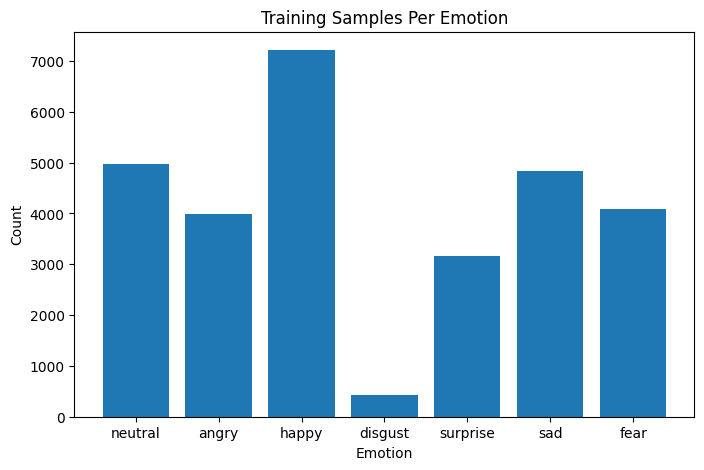

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.bar(
    df_counts["Emotion"],
    df_counts["Count"]
)

plt.title("Training Samples Per Emotion")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()

In [ ]:
import cv2
import matplotlib.pyplot as plt

def show_sample(emotion):
  folder = f"train/{emotion}"
  image_name=os.listdir(folder)[0]
  image_path=os.path.join(folder, image_name)
  image=cv2.imread(
      image_path,
      cv2.IMREAD_GRAYSCALE
  )
  plt.imshow(image, cmap="grey")
  plt.title(emotion)
  plt.axis("off")
  plt.show()

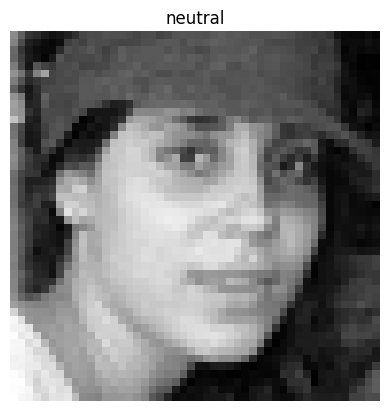

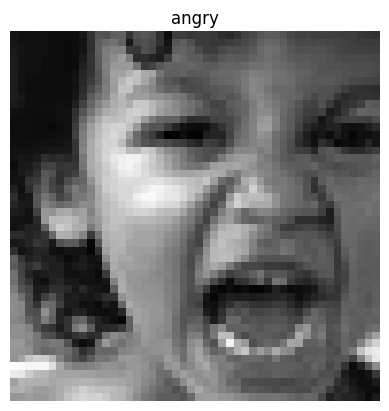

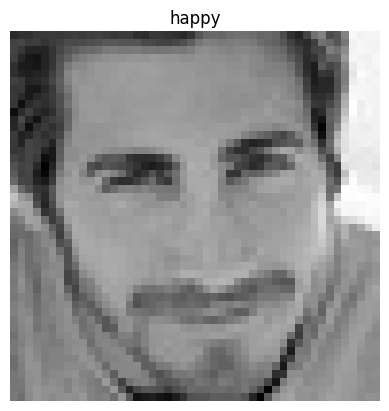

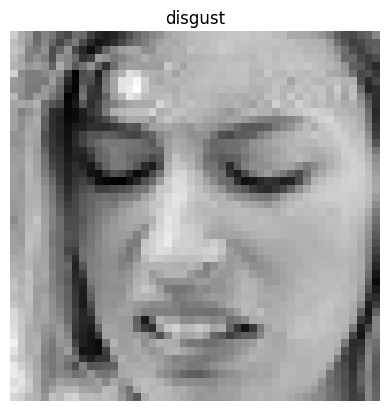

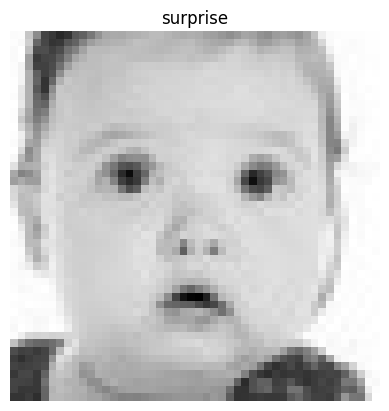

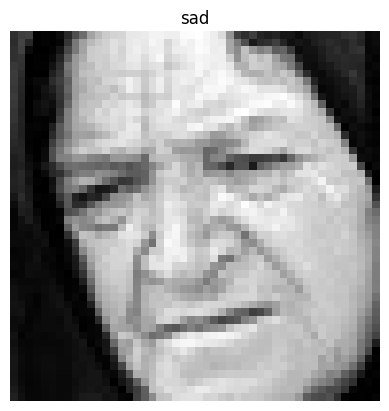

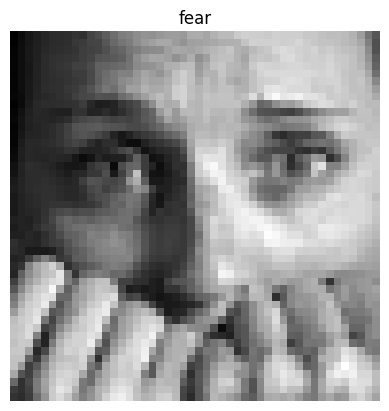

In [ ]:
for emotion in os.listdir("train"):
    show_sample(emotion)

In [ ]:
sample_path = "train/happy/" + os.listdir("train/happy")[0]

img = cv2.imread(
    sample_path,
    cv2.IMREAD_GRAYSCALE
)

print(img.shape)

(48, 48)


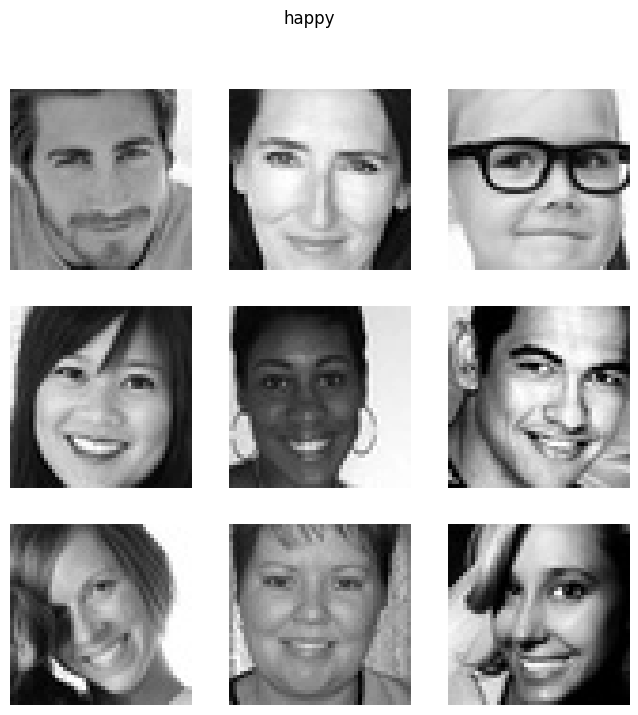

In [ ]:
emotion = "happy"

files = os.listdir(f"train/{emotion}")[:9]

plt.figure(figsize=(8,8))

for i,file in enumerate(files):

    img = cv2.imread(
        f"train/{emotion}/{file}",
        cv2.IMREAD_GRAYSCALE
    )

    plt.subplot(3,3,i+1)
    plt.imshow(img,cmap="gray")
    plt.axis("off")

plt.suptitle(emotion)
plt.show()

## Initial Dataset Observations

- Dataset contains 7 emotion classes.
- Images are grayscale.
- Resolution is 48x48.
- Emotion classes are imbalanced.
- Disgust has significantly fewer samples.
- Some faces are blurry or partially cropped.
- Images appear suitable for CNN training.

In [ ]:
for emotion, count in class_counts.items():
    percentage = count / total_images * 100
    print(f"{emotion}: {percentage:.2f}%")

neutral: 17.29%
angry: 13.92%
happy: 25.13%
disgust: 1.52%
surprise: 11.05%
sad: 16.82%
fear: 14.27%


## Class Imbalance Observation

The FER2013 dataset is not balanced across emotion classes.

Happy has the highest number of training samples (7215).

Disgust has only 436 samples, making it severely underrepresented.

This may lead to poor classification performance for the disgust class and will need to be monitored during evaluation.

In [ ]:
!pip install datasets

In [ ]:
import datasets
import huggingface_hub

print("datasets:", datasets.__version__)
print("huggingface_hub:", huggingface_hub.__version__)

datasets: 4.0.0
huggingface_hub: 1.17.0


In [ ]:
!pip install -U datasets huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 684.4/684.4 kB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 13.2 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.17.0
    Uninstalling huggingface_hub-1.17.0:
      Successfully uninstalled huggingface_hub-1.17.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [ ]:
from datasets import load_dataset
imdb = load_dataset("imdb")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


HfUriError: Invalid HF URI 'hf://datasets/imdb@e6281661ce1c48d982bc483cf8a173c1bbeb5d31/.huggingface.yaml'. Repository id must be 'namespace/name', got 'imdb'.

In [ ]:
!pip uninstall -y datasets huggingface_hub
!pip install datasets==3.6.0

Found existing installation: datasets 3.6.0
Uninstalling datasets-3.6.0:
  Successfully uninstalled datasets-3.6.0
Found existing installation: huggingface_hub 1.18.0
Uninstalling huggingface_hub-1.18.0:
  Successfully uninstalled huggingface_hub-1.18.0
  Using cached datasets-3.6.0-py3-none-any.whl.metadata (19 kB)
  Using cached huggingface_hub-1.18.0-py3-none-any.whl.metadata (14 kB)
Using cached datasets-3.6.0-py3-none-any.whl (491 kB)
Using cached huggingface_hub-1.18.0-py3-none-any.whl (684 kB)


In [ ]:
import datasets
import huggingface_hub

print("datasets:", datasets.__version__)
print("huggingface_hub:", huggingface_hub.__version__)

datasets: 3.6.0
huggingface_hub: 1.18.0


In [ ]:
!pip uninstall -y datasets huggingface_hub
!pip install -q datasets==4.0.0 huggingface_hub==0.34.4

Found existing installation: datasets 3.6.0
Uninstalling datasets-3.6.0:
  Successfully uninstalled datasets-3.6.0
Found existing installation: huggingface_hub 1.18.0
Uninstalling huggingface_hub-1.18.0:
  Successfully uninstalled huggingface_hub-1.18.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.8/494.8 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.5/561.5 kB 22.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 5.9.0 requires huggingface-hub<2.0,>=1.5.0, but you have huggingface-hub 0.34.4 which is incompatible.


In [ ]:
!wget -q https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz

!tar -xzf aclImdb_v1.tar.gz

In [ ]:
import os

print(os.listdir("aclImdb"))

['imdb.vocab', 'test', 'imdbEr.txt', 'train', 'README']


In [ ]:
for root, dirs, files in os.walk("aclImdb/train"):
    print(root, len(files))

aclImdb/train 5
aclImdb/train/unsup 50000
aclImdb/train/neg 12500
aclImdb/train/pos 12500


In [ ]:
import os

reviews = []
labels = []

base_path = "aclImdb/train"

for sentiment in ["pos", "neg"]:

    folder = os.path.join(base_path, sentiment)

    for file_name in os.listdir(folder):

        file_path = os.path.join(folder, file_name)

        with open(file_path, "r", encoding="utf-8") as f:

            reviews.append(f.read())

            labels.append(
                1 if sentiment == "pos" else 0
            )

In [ ]:
import pandas as pd

train_df = pd.DataFrame({
    "review": reviews,
    "label": labels
})

train_df.head()

,review,label
0,yes i have a copy of it on VHS uncut in great ...,1
1,Not being a fan of first person shooters I was...,1
2,Unique movie about confused woman (Lindsay Cro...,1
3,<br /><br />Everything is relative seems to be...,1
4,I have just watched the whole 6 episodes on DV...,1


In [ ]:
print("Number of reviews:", len(train_df))

Number of reviews: 25000


In [ ]:
train_df["label"].value_counts()

,count
label,
1,12500
0,12500


In [ ]:
print(train_df.iloc[0]["review"][:500])

yes i have a copy of it on VHS uncut in great condition that i transfered to DVD and if anyone one wants to bring back the memories of a Christmas classic please emil me at dmd2222@verizon.net.i searched everywhere and i found nothing on this and i thought that i cant be the only one on this planet that has this classic on tape there has to be other people and if they do i fit in with them being that very very few that has this classic so i consider myself lucky and i have all of the muppets Chr


In [ ]:
train_df.shape

(25000, 2)

## NLP Exploratory Data Analysis

In [ ]:
train_df["char_length"] = train_df["review"].apply(len)

In [ ]:
train_df["char_length"].describe()

,char_length
count,25000.00000
mean,1325.06964
std,1003.13367
min,52.00000
25%,702.00000
50%,979.00000
75%,1614.00000
max,13704.00000


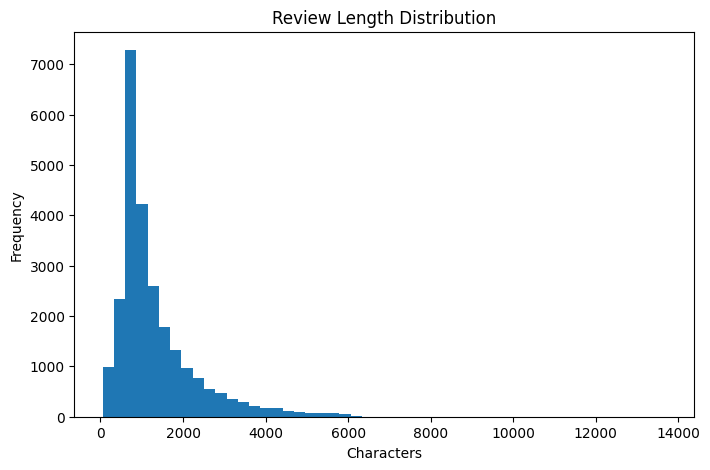

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    train_df["char_length"],
    bins=50
)

plt.title("Review Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.show()

In [ ]:
train_df["word_count"] = train_df["review"].apply(
    lambda x: len(x.split())
)

In [ ]:
train_df["word_count"].describe()

,word_count
count,25000.000000
mean,233.787200
std,173.733032
min,10.000000
25%,127.000000
50%,174.000000
75%,284.000000
max,2470.000000


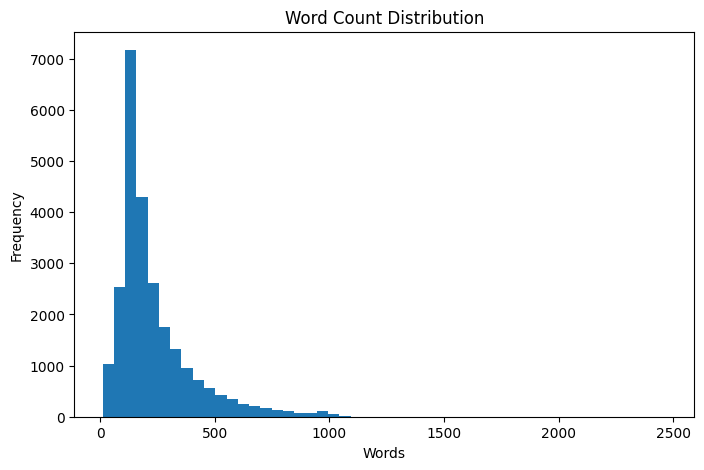

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    train_df["word_count"],
    bins=50
)

plt.title("Word Count Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.show()

In [ ]:
train_df.groupby("label")["word_count"].mean()

,word_count
label,
0,230.86784
1,236.70656


In [ ]:
for i in range(3):

    print("="*100)

    print(train_df.iloc[i]["review"][:1000])

    print("\n")

yes i have a copy of it on VHS uncut in great condition that i transfered to DVD and if anyone one wants to bring back the memories of a Christmas classic please emil me at dmd2222@verizon.net.i searched everywhere and i found nothing on this and i thought that i cant be the only one on this planet that has this classic on tape there has to be other people and if they do i fit in with them being that very very few that has this classic so i consider myself lucky and i have all of the muppets Christmas except one that john denver did with the muppets again i thinks its called a smokey mountain holiday im not to sure but its close.


Not being a fan of first person shooters I was very hesitant to play this game. After having played the demo however I was sold. "Undying" really manages to pull you in the game and be part of the universe that your character is in. You have this green amulet,called the "Gel'ziabar Stone" that has special powers and warns you of particular events or things t

* Contains HTML tags
* Contains punctuation
* Contains contractions
* Contains numbers
* Contains repeated characters

In [ ]:
from collections import Counter

In [ ]:
all_words = []

for review in train_df["review"][:5000]:

    all_words.extend(
        review.split()
    )

In [ ]:
word_counts = Counter(all_words)

word_counts.most_common(20)

[('the', 59408),
 ('and', 33958),
 ('a', 31714),
 ('of', 30202),
 ('to', 25978),
 ('is', 22265),
 ('in', 18429),
 ('that', 12794),
 ('I', 12488),
 ('it', 10773),
 ('this', 10362),
 ('/><br', 9760),
 ('as', 9485),
 ('with', 8863),
 ('was', 8396),
 ('for', 8210),
 ('The', 6661),
 ('his', 6630),
 ('but', 6472),
 ('on', 6235)]

In [ ]:
unique_words = set(all_words)

print(len(unique_words))

101218


## NLP Dataset Observations

- Dataset contains 25,000 training reviews.
- Balanced positive and negative classes.
- Reviews vary greatly in length.
- HTML tags are present.
- Punctuation is common.
- Reviews contain mixed casing.
- Common words are mostly stopwords.
- Vocabulary size appears large.

## Modeling Risks

### FER2013

- Class imbalance
- Low resolution images
- Emotion ambiguity

### IMDb

- HTML tags
- Large vocabulary
- Very long reviews
- Noise from punctuation and casing